# Gradient Descent: How Machines Walk Downhill

**DCS 404 · Data Science and Machine Learning**

---

At the end of the OLS derivation last module, I told you to enjoy the closed-form solution while it lasted —
that for most models beyond linear regression, no tidy formula exists, and we'd eventually have to *walk
downhill step by step*. This module is that walk.

**Gradient descent** is the single most important algorithm in machine learning. Not the most sophisticated —
it's almost embarrassingly simple — but the most important, because it's the engine underneath nearly
everything modern. The neural networks behind image recognition, the language models you've chatted with, the
recommendation systems choosing your next video: at the bottom of every one of them, some version of gradient
descent is nudging millions (or billions) of parameters downhill, a little at a time.

Today we build it from nothing. We'll minimise a simple function by hand, watch what the learning rate does
when we get it right and when we get it wrong, then point the algorithm at our linear regression problem from
last module and watch it *learn* the same coefficients that OLS computed in one shot. Along the way we'll hit a
genuine, instructive failure — gradient descent blowing up to infinity on raw data — and fix it with feature
scaling, one of the most practical tricks in the book.

Boots on. Let's find the bottom of this valley.

## How to work through this

Same rhythm as always: run every code cell (`Shift + Enter`), look at the output, *then* read the commentary.
Cells build on each other in order — the linear regression part reuses functions defined earlier — so if
something errors, run from the top.

Today's mathematics is lighter than last module's OLS derivation, but it *builds on it*: we reuse the cost
function idea, the convex bowl, and the Advertising dataset (bundled in `data/`, so everything runs offline).
If the phrase "partial derivative of the SSE" makes you nervous, skim Sections 4–5 of the Regression module
before starting.

One heads-up: in Section 6 we will run code that **deliberately fails** — the cost will race off to infinity.
That's not a bug in your setup; it's the lesson. Watch it happen, then watch us fix it.

## Learning objectives

After completing this module you will be able to:

- Explain when and why we need an iterative optimiser instead of the closed-form OLS solution.
- Describe the gradient descent algorithm: random initialisation, the update rule
  $x := x - \alpha \, \nabla f(x)$, and convergence.
- Implement gradient descent from scratch and use it to minimise an arbitrary function.
- Explain the role of the learning rate, and diagnose the symptoms of one that is too small or too large.
- Explain why non-convex functions can trap gradient descent in a local minimum.
- Derive the gradient of the linear regression cost function and write it as one matrix expression,
  $\mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$.
- Train a multiple linear regression with gradient descent and compare the result against OLS.
- Use feature scaling (standardisation, min-max scaling) to make gradient descent converge dramatically
  faster.

## Setup

Run this once. Same libraries and plotting style as before, plus the Advertising dataset from last module.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression

# A consistent look for every plot in this notebook
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
sns.set_palette("deep")
RANDOM_STATE = 0

# Load the Advertising dataset, checking the usual likely locations.
for candidate in [Path("data/Advertising.csv"),
                  Path("notebooks/data/Advertising.csv"),
                  Path("resources/dataset/Advertising.csv")]:
    if candidate.exists():
        ads = pd.read_csv(candidate, index_col=0)
        print(f"Loaded dataset from: {candidate}")
        break
else:
    raise FileNotFoundError("Could not find Advertising.csv. Expected it in a data/ folder next to the notebook.")

print(f"Shape: {ads.shape[0]} markets, {ads.shape[1]} columns")
ads.head()

Loaded dataset from: data/Advertising.csv
Shape: 200 markets, 4 columns


,TV,radio,newspaper,sales
1,230.1,37.8,69.2,22.1
2,44.5,39.3,45.1,10.4
3,17.2,45.9,69.3,9.3
4,151.5,41.3,58.5,18.5
5,180.8,10.8,58.4,12.9


---
## 1. Why walk when you can teleport? The case for iteration

Last module, OLS felt like magic: write down the loss, take derivatives, and out drops a *formula* for the
best parameters. For multiple regression the formula is the **normal equation**,

$$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$$

— plug in the data, do a fixed amount of arithmetic, and the optimal parameters appear in a single shot. No
searching. Teleportation.

So why would anyone ever do it differently? Three reasons, and they matter more each year:

- **The inverse may not exist.** The normal equation needs $(\mathbf{X}^\top\mathbf{X})^{-1}$, and that
  breaks exactly when our old enemy from last module — perfect multicollinearity — shows up, or when you have
  more features than samples ($d > n$). No inverse, no teleport.
- **The inverse is expensive.** Inverting that matrix costs on the order of $O(d^3)$ operations in the number
  of features $d$. At $d = 3$ that's nothing. At $d = 100{,}000$ — routine for text or image models — it's
  hopeless.
- **Most models have no formula at all.** Linear regression is the lucky special case. For logistic
  regression, neural networks, and nearly everything else ahead of us, no amount of algebra produces a
  closed-form solution. Iteration isn't an alternative there; it's the only game in town.

The **iterative approach** trades the teleport for a walk: start from a *random guess*, then repeatedly apply
an *update rule* that makes the guess a little better, until the improvements dry up. Gradient descent is the
simplest and most popular member of this family — a *first-order* method, meaning the only information it
needs about the function is its first derivative.

---
## 2. A hiker in the fog

The classic picture, and honestly the one professionals still think in. You're standing on a hillside in fog
so thick you can see nothing — but you can *feel the slope under your feet*. How do you reach the valley
floor? Feel which direction is steepest downhill, take a step that way. Steep slope, confident stride; gentle
slope, cautious shuffle. Repeat. When the ground feels flat in every direction, you're at the bottom — or at
least at *a* bottom (hold that worry until Section 5).

Now translate every piece. The hill is the function $f$ we want to minimise. Your position is the current
parameter value. And the slope under your feet is the **gradient**: at any point, the gradient of a function
points in the direction of *steepest ascent*, and its magnitude says how steep the function is there. So the
*negative* gradient points steepest-downhill — and taking steps proportional to it is exactly the fog
strategy, formalised.

### The algorithm

To minimise a function $f$:

1. **Initialise** $x$ randomly — anywhere on the hill.
2. **Compute the gradient** at the current position, $\frac{\partial f(x)}{\partial x}$.
3. **Update** the position by stepping against the gradient:

$$x := x - \alpha \, \frac{\partial f(x)}{\partial x}$$

   where $\alpha$ (alpha) is the **learning rate** — a small constant controlling the step size — and $:=$
   means "assign" (the new $x$ is computed from the old one).

4. **Repeat** steps 2–3 until $f(x)$ stops improving.

Notice the built-in braking system: as we approach a minimum, the gradient shrinks toward zero, so the steps
shrink too — long confident strides on the steep upper slopes, tiny careful ones near the flat bottom. At the
minimum itself $\frac{\partial f}{\partial x} \approx 0$ and the updates effectively stop. That's
**convergence**.

---
## 3. Gradient descent from scratch, on the simplest possible hill

Ten lines of Python. That's the whole engine of modern machine learning:

In [2]:
def gradient_descent_1d(gradient, x_init, alpha=0.01, max_iters=10000, precision=1e-8):
    """Minimise a 1-D function by gradient descent, keeping the path for plotting."""
    x = x_init
    path = [x]
    while abs(gradient(x)) > precision and len(path) <= max_iters:
        x = x - alpha * gradient(x)      # the update rule: step against the gradient
        path.append(x)
    return x, path

Our test hill is the parabola $f(x) = x^2 + 3x - 5$. Its gradient is $\frac{df}{dx} = 2x + 3$, which we can
differentiate in our heads — and we can also solve $2x + 3 = 0$ in our heads, so we know the true answer is
$x = -1.5$ with $f(-1.5) = -7.25$. That's the point: we're testing the algorithm on a problem where we already
know the answer, exactly like checking our hand-rolled OLS against scikit-learn.

In [3]:
def f(x):
    return x**2 + 3*x - 5

def gradient_f(x):
    return 2*x + 3

x_init = 2.4     # an arbitrary starting guess
alpha = 0.25

x_optimal, path = gradient_descent_1d(gradient_f, x_init, alpha=alpha)
print(f"optimal x:    {x_optimal:.6f}   (true answer: -1.5)")
print(f"min f(x):     {f(x_optimal):.6f}   (true answer: -7.25)")
print(f"no. of steps: {len(path) - 1}")

optimal x:    -1.500000   (true answer: -1.5)
min f(x):     -7.250000   (true answer: -7.25)
no. of steps: 30


Starting from a blind guess of $x = 2.4$, the algorithm walked to the true minimum in a few dozen steps.
Because our function kept the whole `path`, we can watch every step of the descent — the computational version
of the animation below.

<center>
<img src="resources/images/gd_animation.gif" width="420">

Fig: Gradient descent walking down a convex function, step by step
</center>

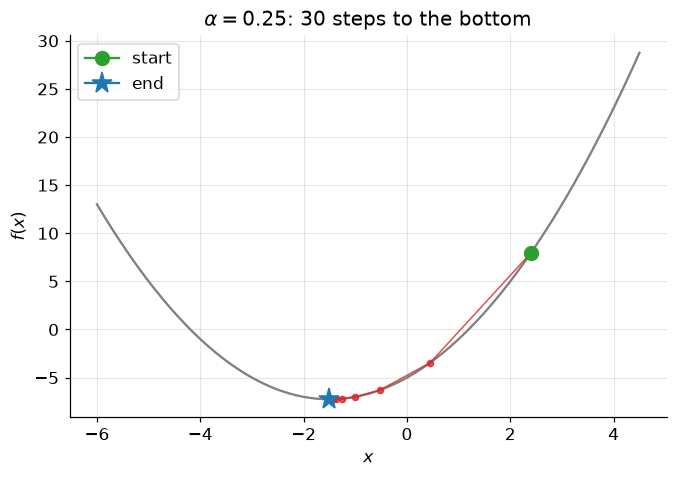

In [4]:
def plot_descent(path, ax=None, title=None):
    """Overlay a descent path on the graph of f."""
    ax = ax or plt.gca()
    xs = np.linspace(-6, 4.5, 200)
    ax.plot(xs, f(xs), color="grey", linewidth=1.5)
    path = np.asarray(path)
    ax.plot(path, f(path), marker="o", markersize=4, color="tab:red",
            linewidth=1, alpha=0.8)
    ax.plot(path[0], f(path[0]), marker="o", markersize=9, color="tab:green", label="start")
    ax.plot(path[-1], f(path[-1]), marker="*", markersize=14, color="tab:blue", label="end")
    ax.set_xlabel("$x$")
    ax.set_ylabel("$f(x)$")
    if title:
        ax.set_title(title)
    ax.legend()


plot_descent(path, title=f"$\\alpha = {alpha}$: {len(path)-1} steps to the bottom")
plt.show()

Exactly the fog strategy: big early strides where the parabola is steep, then progressively daintier steps as
the gradient fades near the bottom, until the updates are too small to matter. Each red dot is one iteration
of the update rule — nothing more than `x = x - alpha * gradient(x)`, repeated.

---
## 4. The learning rate: the one knob that matters

The learning rate $\alpha$ is the first **hyperparameter** you've met — a setting *we* choose rather than a
value the algorithm learns. It scales every step, it stays fixed throughout the run, and getting it wrong is
the number-one way gradient descent goes bad. There are exactly two ways to get it wrong.

**Too small**, and every step is a timid shuffle: the algorithm still converges, but takes ages doing it.

<center>
<img src="resources/images/gd_small_lr.gif" width="420">

Fig: A too-small learning rate — shuffling down the hill
</center>

**Too large**, and the algorithm overshoots the minimum and lands on the *opposite slope* — then overshoots
back. It zig-zags across the valley, and if $\alpha$ is large enough, each jump lands *higher* than the last
and the whole thing diverges.

<center>
<img src="resources/images/gd_large_lr.gif" width="420">

Fig: A too-large learning rate — overshooting from slope to slope
</center>

Don't take the animations' word for it. Same function, same starting point, three learning rates:

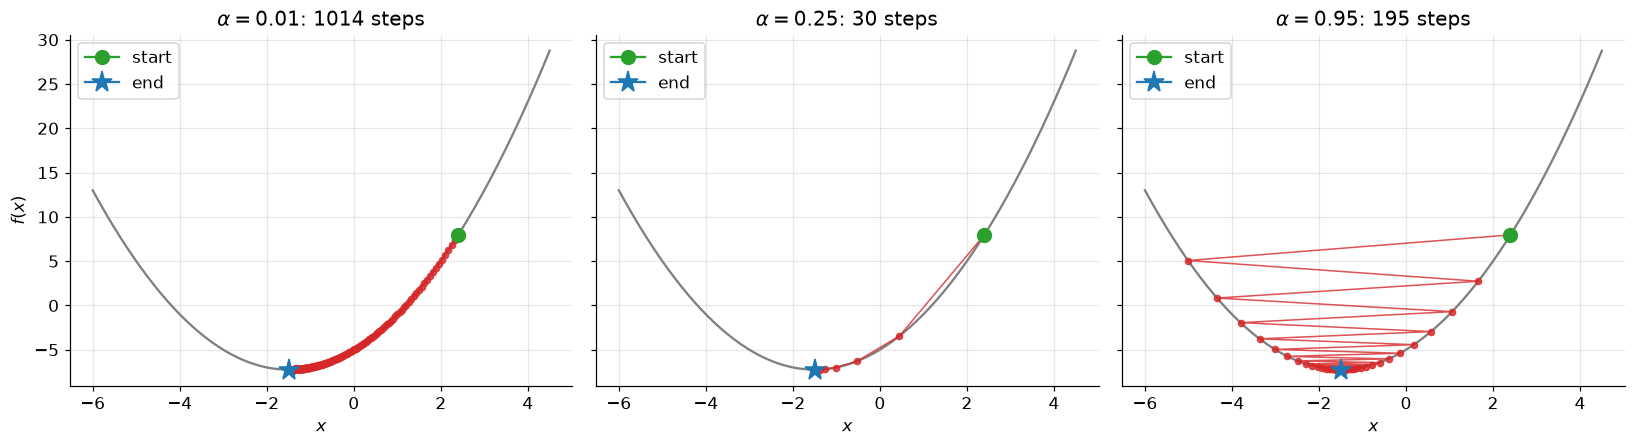

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)

for ax, a in zip(axes, [0.01, 0.25, 0.95]):
    _, p = gradient_descent_1d(gradient_f, x_init, alpha=a)
    plot_descent(p, ax=ax, title=f"$\\alpha = {a}$: {len(p)-1} steps")
    ax.set_ylabel("")
axes[0].set_ylabel("$f(x)$")
plt.tight_layout()
plt.show()

Read the three panels as a fable:

- **$\alpha = 0.01$** creeps down the hill in over a thousand tiny steps — so many that the red dots blur into
  a solid line. It gets there, eventually. (In real projects where each step means a pass over millions of data
  points, "eventually" is a budget problem.)
- **$\alpha = 0.25$** is the porridge that's just right: a few dozen decisive steps.
- **$\alpha = 0.95$** never walks downhill at all — it *ricochets* across the valley, from one slope to the
  other, each bounce a little lower, and takes more steps than $0.25$ despite moving four times as boldly.
  Nudge it a little higher still and the bounces grow instead of shrinking: divergence. Try $\alpha = 1.05$ in
  the cell above and watch (then put it back).

There's no formula for the right $\alpha$ — in practice you try a few values spaced by factors of ~10 (0.001,
0.01, 0.1) and watch the cost curve. Fancier *adaptive learning rate* methods (Adam and friends) adjust the
step size on the fly, and they await you in any deep learning course. The intuition you just built is exactly
the one they automate.

---
## 5. Valleys with false bottoms: non-convex functions

Everything so far worked because our parabola — like last module's SSE bowl — is **convex**: one valley, one
bottom, and every downhill walk ends at the same global minimum. Gradient descent literally cannot fail on
such a function (with a sane $\alpha$).

<center>
<img src="resources/images/convex_function.png" width="440">

Fig: A convex function — the only minimum is the global one
</center>

But nothing guarantees the functions we'll meet later are convex. A non-convex function has **multiple
valleys**: one true *global minimum* and any number of shallower *local minima*.

<center>
<img src="resources/images/nonconvex_function.png" width="440">

Fig: A non-convex function — local minima can trap the walker
</center>

And here's the trap: gradient descent only feels the slope under its feet. Walk downhill into a shallow
valley, reach its floor, feel flat ground in every direction — and stop, satisfied, with no way to know that a
much deeper valley lies over the next ridge. **Where you start determines where you finish.** Watch it happen:

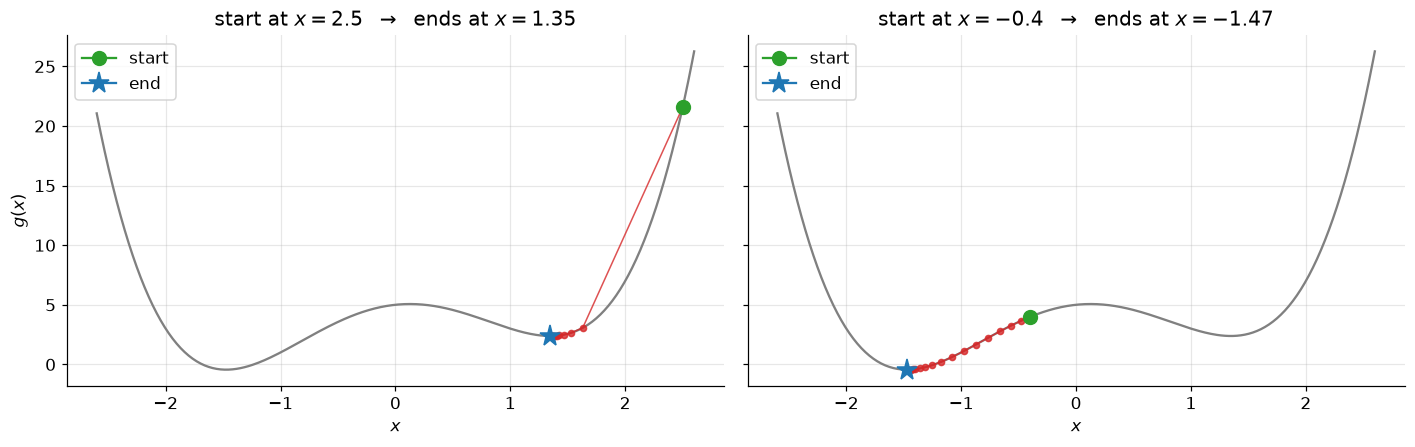

In [6]:
# A non-convex hill: two valleys of different depths
def g(x):
    return x**4 - 4*x**2 + x + 5

def gradient_g(x):
    return 4*x**3 - 8*x + 1

xs = np.linspace(-2.6, 2.6, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharey=True)
for ax, start in zip(axes, [2.5, -0.4]):
    x_end, p = gradient_descent_1d(gradient_g, x_init=start, alpha=0.02)
    p = np.asarray(p)
    ax.plot(xs, g(xs), color="grey", linewidth=1.5)
    ax.plot(p, g(p), marker="o", markersize=4, color="tab:red", linewidth=1, alpha=0.8)
    ax.plot(start, g(start), marker="o", markersize=9, color="tab:green", label="start")
    ax.plot(x_end, g(x_end), marker="*", markersize=14, color="tab:blue", label="end")
    ax.set_title(f"start at $x = {start}$  $\\rightarrow$  ends at $x = {x_end:.2f}$")
    ax.set_xlabel("$x$")
    ax.legend()
axes[0].set_ylabel("$g(x)$")
plt.tight_layout()
plt.show()

Same function, same learning rate, same algorithm — two different answers. The walker starting at $x = 2.5$
descends into the right-hand valley, feels flat ground at its floor, and stops — at a *local* minimum,
blissfully unaware that a better answer exists a short climb away. The walker starting at $x = -0.4$ happens
to roll leftward instead, into the deeper valley, and finds the true *global* minimum. Neither walker did
anything wrong; one just started on the luckier slope. This is the honest weakness of gradient descent, and it's why practitioners
sometimes run from several random initialisations and keep the best result.

The good news for today: our linear regression cost function is convex — we proved as much last module when we
met the SSE bowl. No false bottoms ahead. Let's go fit the model.

---
## 6. Gradient descent for linear regression

Time to reunite with the Advertising dataset. Last module we fitted

$$\text{sales} = \beta_0 + \beta_1 \cdot \text{TV} + \beta_2 \cdot \text{radio} + \beta_3 \cdot \text{newspaper}$$

by OLS. Now we'll make gradient descent *learn* those same four parameters — but first, a piece of
housekeeping that pays for itself many times over: writing the problem in **matrix form**.

Stack all $n = 200$ predictions into one vector equation:

$$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol\beta
\qquad\qquad
\begin{bmatrix} \hat{y}_1 \\ \hat{y}_2 \\ \vdots \\ \hat{y}_{200} \end{bmatrix}
=
\begin{bmatrix}
1 & x_{1,1} & x_{1,2} & x_{1,3} \\
1 & x_{2,1} & x_{2,2} & x_{2,3} \\
\vdots & \vdots & \ddots & \vdots \\
1 & x_{200,1} & x_{200,2} & x_{200,3}
\end{bmatrix}
\times
\begin{bmatrix} \beta_0 \\ \beta_1 \\ \beta_2 \\ \beta_3 \end{bmatrix}$$

The matrix $\mathbf{X}$ (the *design matrix*) holds one row per market and one column per feature — plus a
first column of all 1s. That column is a lovely trick: it lets the intercept $\beta_0$ ride along as just
another coefficient, "multiplying" a feature that always equals 1, so one matrix product computes every
prediction for every market at once.

In [7]:
# Design matrix: a column of ones, then the three feature columns
X = ads[["TV", "radio", "newspaper"]].values
X = np.c_[np.ones((X.shape[0], 1)), X]

y = ads["sales"].values.reshape(-1, 1)

n, d = X.shape   # 200 samples, 4 columns (ones + 3 features)
print(f"n = {n} samples,  d = {d} columns")
print("first two rows of X:")
print(X[:2])

n = 200 samples,  d = 4 columns
first two rows of X:
[[  1.  230.1  37.8  69.2]
 [  1.   44.5  39.3  45.1]]


### 6.1 The cost function

We'll minimise the same sum of squared errors as OLS, with one cosmetic tweak — a factor of $\frac{1}{2}$ out
front:

$$J(\boldsymbol\beta) = \frac{1}{2}\sum_{i=1}^{n}(\hat{y}_i - y_i)^2$$

Why the half? Pure convenience: differentiating the square brings down a 2, and the $\frac{1}{2}$ cancels it,
leaving cleaner gradients. Scaling a function by a positive constant moves its *values* but not the location
of its minimum, so the optimal $\boldsymbol\beta$ is untouched. (Note also that $J$ is a function of
$\boldsymbol\beta$ alone — $\mathbf{X}$ and $\mathbf{y}$ are fixed by the dataset; the parameters are the only
things that move.)

### 6.2 The gradient

We need $\frac{\partial J}{\partial \beta_j}$ for each parameter. The derivation is last module's, re-run with
the chain rule doing the talking. For $\beta_1$:

$$\frac{\partial J}{\partial \beta_1}
= \frac{1}{2}\sum_{i=1}^{n}\frac{\partial}{\partial \beta_1}(\hat{y}_i - y_i)^2
= \frac{1}{2}\sum_{i=1}^{n} 2(\hat{y}_i - y_i)\cdot\frac{\partial \hat{y}_i}{\partial \beta_1}
= \sum_{i=1}^{n}(\hat{y}_i - y_i)\,x_{i,1}$$

(the 2 and the $\frac{1}{2}$ cancel, exactly as promised, and $\hat{y}_i$ depends on $\beta_1$ only through
the term $\beta_1 x_{i,1}$). Nothing about that calculation was specific to $\beta_1$, so for *every*
parameter $\beta_j$:

$$\frac{\partial J}{\partial \beta_j} = \sum_{i=1}^{n}(\hat{y}_i - y_i)\,x_{i,j}$$

— and for $\beta_0$, whose "feature" is the column of 1s, the gradient is simply the sum of the errors. Even
better, all four partial derivatives collapse into a single matrix expression:

$$\frac{\partial J}{\partial \boldsymbol\beta} = \mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$$

One transpose, one subtraction, one matrix product — the entire gradient, for any number of features. This is
why we bothered with matrix form.

### 6.3 The pieces, in code

In [8]:
def initialize_betas(d, seed=RANDOM_STATE):
    """Random starting parameters, drawn from a standard normal distribution."""
    rng = np.random.default_rng(seed)
    return rng.standard_normal((d, 1))

def calculate_cost(X, y, betas):
    """J(beta) = 1/2 * sum of squared errors."""
    return 0.5 * np.sum(np.square(X @ betas - y))

def calculate_gradients(X, y, betas):
    """dJ/dbeta = X^T (y_hat - y), all parameters at once."""
    return X.T @ (X @ betas - y)

betas = initialize_betas(d)
print("initial betas:", betas.ravel().round(4))
print(f"initial cost: {calculate_cost(X, y, betas):,.0f}")
print("initial gradients:", calculate_gradients(X, y, betas).ravel().round(0))

initial betas: [ 0.1257 -0.1321  0.6404  0.1049]
initial cost: 51,225
initial gradients: [  -3044. -699922.  -51043.  -76447.]


Look at those gradients before moving on — the ledger tells a story. The gradient for the TV coefficient is
around seven hundred *thousand*, while the one for the intercept is more than two hundred times smaller. Why? Look at the general
formula: the gradient for $\beta_j$ is a sum of errors *times the feature values* $x_{i,j}$. TV budgets run
up to nearly 300, radio and newspaper only to about 50 and 114, and the ones column is stuck at 1 — so
parameters attached to big-valued features get big gradients. File that observation away; it detonates in
about two cells.

### 6.4 The descent loop

The update is the same rule as Section 2, applied to all four parameters at once:
$\boldsymbol\beta := \boldsymbol\beta - \alpha\,\frac{\partial J}{\partial \boldsymbol\beta}$. We stop when an
update improves the cost by less than a small threshold (convergence) or when we run out of iterations — and,
having been warned, we also bail out if the cost explodes.

In [9]:
def gradient_descent(X, y, alpha=0.003, max_iters=10000, precision=1e-3, seed=RANDOM_STATE):
    """Fit linear regression by gradient descent. Returns (betas, n_iterations, cost_history)."""
    d = X.shape[1]
    betas = initialize_betas(d, seed=seed)
    costs = [calculate_cost(X, y, betas)]

    for iteration in range(1, max_iters + 1):
        betas = betas - alpha * calculate_gradients(X, y, betas)   # the update rule
        cost = calculate_cost(X, y, betas)
        costs.append(cost)

        if not np.isfinite(cost):
            print(f"Diverged: cost reached infinity at iteration {iteration}. Try a smaller learning rate.")
            break
        if abs(costs[-2] - cost) < precision:                      # converged: cost stopped improving
            break

    return betas, iteration, costs

Moment of truth. Let's train with a seemingly innocent learning rate, $\alpha = 0.003$:

In [10]:
with np.errstate(over="ignore", invalid="ignore"):   # we *expect* this to overflow
    betas_raw, steps, costs = gradient_descent(X, y, alpha=0.003)

print(f"final cost: {costs[-1]}")

Diverged: cost reached infinity at iteration 36. Try a smaller learning rate.
final cost: inf


Boom. A learning rate that would be considered *tiny* in most settings sent the cost to infinity within a
few dozen iterations. This is the observation from Section 6.3 detonating: the gradients are in the millions
because the TV feature has large values, so even multiplied by $0.003$, each "step" hurls the parameters
thousands of units across the loss surface — far past the minimum, onto ever-steeper slopes. Ricochet, but
each bounce higher. Divergence.

We can rescue the run by shrinking $\alpha$ until the steps are sane again. It takes an absurd-looking value:

stopped after 10000 iterations (the max_iters cap)
final cost: 375.7 — and still improving by 0.0017 per step, so not yet converged
betas: [0.3572 0.0528 0.2181 0.0146]


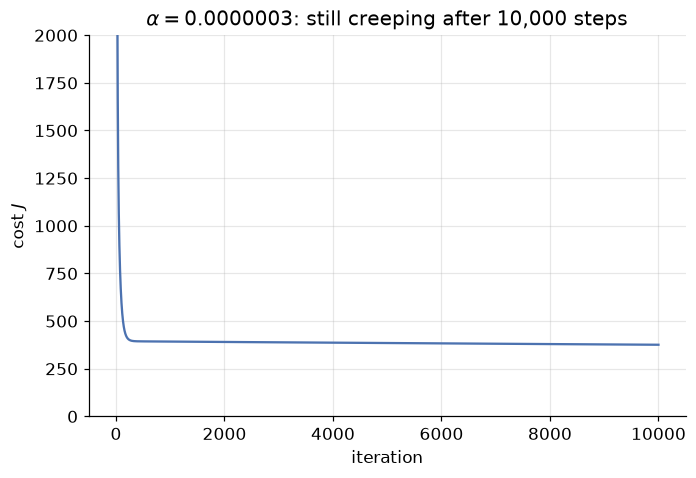

In [11]:
betas_raw, steps_raw, costs_raw = gradient_descent(X, y, alpha=0.0000003)

print(f"stopped after {steps_raw} iterations (the max_iters cap)")
print(f"final cost: {costs_raw[-1]:.1f} — and still improving by "
      f"{abs(costs_raw[-2] - costs_raw[-1]):.4f} per step, so not yet converged")
print("betas:", betas_raw.ravel().round(4))

plt.plot(costs_raw)
plt.xlabel("iteration")
plt.ylabel("cost $J$")
plt.ylim(0, 2000)
plt.title(f"$\\alpha = 0.0000003$: still creeping after {steps_raw:,} steps")
plt.show()

The cost curve slides down and flattens — the signature shape of a training run (you'll draw a thousand of
these curves in your ML career; this is your first). But look closer at the printout: after **ten thousand**
iterations the run hit its cap and the cost is *still* inching downward — it never actually converged. And we
can't speed it up: nudge the learning rate up to just $0.0000005$ and the whole thing diverges to infinity
again (try it). The usable window for $\alpha$ is razor-thin, and even its best value crawls. We're stuck in
the worst-of-both-worlds from Section 4 — an $\alpha$ small enough not to explode on the huge TV gradients is
far too small to make progress for everyone else.

The root cause isn't the learning rate at all. It's that our features live on wildly different scales, so no
single $\alpha$ suits them all. Fix the scales, fix the problem.

---
## 7. Feature scaling: the fix

**Feature scaling** transforms every feature to a similar, small range. The step gradient descent takes for
each parameter depends on two things — the learning rate (shared by all parameters) and the gradient (which,
as we saw, scales with the feature's values). When features share a scale, their gradients share a scale, one
sensible learning rate suits everyone, and the descent stops being a hostage to its largest feature.

The two workhorse techniques:

**Standardisation** rescales each feature to have mean 0 and standard deviation 1:

$$x' = \frac{x - \mu}{\sigma}$$

where $\mu$ and $\sigma$ are the feature's mean and standard deviation. It's the default choice for algorithms
that like normally-distributed inputs (linear and logistic regression, PCA), and it handles outliers
relatively gracefully.

**Min-max scaling** squashes each feature into the interval $[0, 1]$:

$$x' = \frac{x - \min(x)}{\max(x) - \min(x)}$$

Useful when you want a bounded range and make no distributional assumptions — but because it's built from the
two most extreme values in the data, a single wild outlier can crush every other value into a corner. We'll
use standardisation.

First, how bad is the scale mismatch?

In [12]:
ads[["TV", "radio", "newspaper"]].describe().loc[["min", "mean", "max", "std"]].round(2)

,TV,radio,newspaper
min,0.70,0.00,0.30
mean,147.04,23.26,30.55
max,296.40,49.60,114.00
std,85.85,14.85,21.78


TV spans 0.7 to 296.4; radio never leaves 0 to 49.6. Let's standardise all three feature columns (leaving
the ones column alone — it's doing its intercept job just fine) and confirm the result has mean 0 and standard
deviation 1.

In [13]:
X_scaled = X.copy()
for j in range(1, d):                     # columns 1..3; column 0 is the ones column
    X_scaled[:, j] = (X_scaled[:, j] - X_scaled[:, j].mean()) / X_scaled[:, j].std()

check = pd.DataFrame(X_scaled[:, 1:], columns=["TV", "radio", "newspaper"])
check.agg(["mean", "std"]).round(2)

,TV,radio,newspaper
mean,0.0,-0.0,0.0
std,1.0,1.0,1.0


Every feature now speaks the same language. Rerun gradient descent — same code, same random initialisation,
and the very learning rate that exploded a moment ago:

converged after 13 iterations (raw features: still unconverged after 10,000)
final cost: 278.4  (raw features got to 375.7)


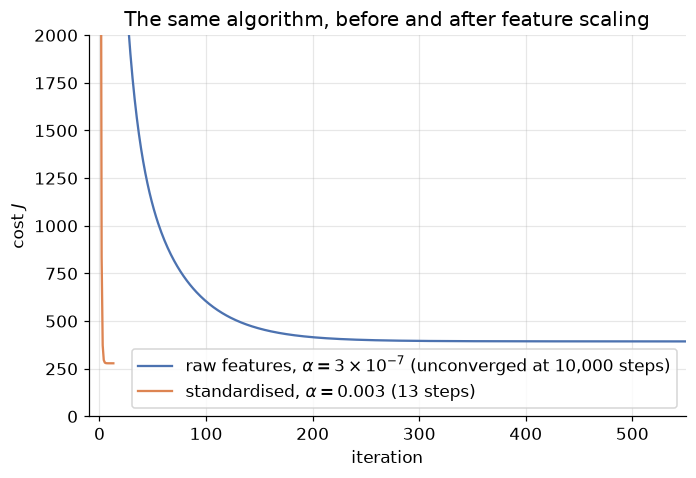

In [14]:
betas_scaled, steps_scaled, costs_scaled = gradient_descent(X_scaled, y, alpha=0.003)

print(f"converged after {steps_scaled} iterations "
      f"(raw features: still unconverged after {steps_raw:,})")
print(f"final cost: {costs_scaled[-1]:.1f}  (raw features got to {costs_raw[-1]:.1f})")

plt.plot(costs_raw, label=f"raw features, $\\alpha=3\\times10^{{-7}}$ (unconverged at {steps_raw:,} steps)")
plt.plot(costs_scaled, label=f"standardised, $\\alpha=0.003$ ({steps_scaled} steps)")
plt.xlabel("iteration")
plt.ylabel("cost $J$")
plt.ylim(0, 2000)
plt.xlim(-10, 550)
plt.title("The same algorithm, before and after feature scaling")
plt.legend()
plt.show()

Night and day. On standardised features the cost plummets and converges in **thirteen** iterations — where
the raw-feature run was still unconverged after ten thousand — and it reaches a *lower* final cost, because
the well-conditioned problem lets the optimiser actually arrive at the bottom instead of creeping toward it
forever. Same algorithm, same stopping rule, same data; the only thing that changed is the units.

This is the punchline to remember for the rest of the course: **gradient-based learning wants scaled
features**. Almost every model we meet from here on — logistic regression, neural networks — trains by some
descendant of gradient descent, and this same preprocessing step will matter every single time.

### 7.1 But did it learn the right answer?

Converging fast is nice; converging to the *correct place* is the point. One wrinkle: our coefficients are in
"standardised units" — per *standard deviation* of TV spend, not per \$1,000. To compare apples with apples,
we fit scikit-learn's (OLS-based) `LinearRegression` on the same standardised features:

In [15]:
sk = LinearRegression().fit(X_scaled[:, 1:], y)

comparison = pd.DataFrame(
    {"gradient descent": betas_scaled.ravel(),
     "OLS (scikit-learn)": np.r_[sk.intercept_, sk.coef_.ravel()]},
    index=["intercept", "TV", "radio", "newspaper"],
)
comparison.round(4)

,gradient descent,OLS (scikit-learn)
intercept,14.0224,14.0225
TV,3.9192,3.9193
radio,2.7901,2.7921
newspaper,-0.0206,-0.0225


The walker and the teleporter arrive at the same spot, to a few decimal places. Gradient descent genuinely
*learned* the regression — no normal equation, no closed form, just downhill steps — and it found the same
story we discovered last module: strong roles for TV and radio, essentially nothing for newspaper.

Why only *almost* identical? Because gradient descent stops when improvements fall below a threshold, not at
the exact analytic minimum. Tighten `precision` or add iterations and the digits creep closer. The exactness
of OLS is a luxury of linear regression; the *approach* of gradient descent is what generalises to everything
else.

---
## 8. OLS versus gradient descent: when to use which

Both minimise the same cost; the difference is the route.

| | OLS (normal equation) | Gradient descent |
|---|---|---|
| Approach | Direct — one-shot formula | Iterative — repeated update steps |
| Hyperparameters | None | Learning rate $\alpha$, iterations, stopping rule |
| Requirements | $n > d$ and $(\mathbf{X}^\top\mathbf{X})^{-1}$ must exist | None |
| Solution | Exact (when it applies) | Approximate — depends on $\alpha$ and iterations |
| Feature scaling | Not needed | Practically essential |
| Cost | $O(d^3)$ in the number of features | $O(k\,d^2)$ for $k$ iterations |
| Reach | Linear regression only | Nearly every model in ML |

The practical rule of thumb: with few features (up to a few thousand), take the exact answer — use OLS. With
huge feature counts (say, beyond $10{,}000$), or the moment you step beyond linear regression to models with
no closed form, gradient descent is the tool. Scikit-learn embodies the same split: `LinearRegression` solves
the equations directly, while
[`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
fits the identical model by (a stochastic cousin of) gradient descent, built for datasets too large for the
direct solve.

---
## 9. Your turn

Add cells below each exercise and have a go. Exercises 3 and 5 are the ones that will pay off later in the
course.

**Exercise 1 — A new hill.**
Minimise $f(x) = (x-4)^2 + 10$ with `gradient_descent_1d`. Work out the gradient by hand first, then check
the algorithm lands at $x = 4$. How many steps does it need with $\alpha = 0.1$ versus $\alpha = 0.5$?

**Exercise 2 — Find the cliff edge.**
Using the parabola from Section 3, hunt for the boundary of divergence: try $\alpha$ = 0.9, 1.0, 1.05... At
what learning rate does the descent stop converging entirely? (For $f(x) = x^2 + 3x - 5$ there is an exact
critical value — can you reason out what it is from the update rule?)

**Exercise 3 — Escape the local minimum.**
In Section 5, the walker starting at $x = -0.4$ got stuck in the shallow valley. Keeping the start fixed at
$-0.4$, can you find a learning rate that makes it end up in the *deeper* valley instead? What does that tell
you about the relationship between step size and local minima? (This "overshooting as a feature" intuition is
real — it's part of why practitioners sometimes *like* a bit of noise in their optimiser.)

**Exercise 4 — Min-max instead.**
Redo Section 7 using min-max scaling instead of standardisation. Does gradient descent still converge quickly
with $\alpha = 0.003$? Do you end up with the same final cost?

**Exercise 5 — The students, one more time.**
Build a design matrix from the student dataset (`data/student-mat.csv`, `sep=";"`) using `G1`, `G2`, and
`studytime` to predict `G3`. Standardise the features, fit with your `gradient_descent`, and compare the
coefficients against `LinearRegression` on the same scaled features. Which of the three features carries the
weight?

---
## 10. If you remember nothing else

1. When the closed-form OLS solution is unavailable ($d > n$, non-invertible $\mathbf{X}^\top\mathbf{X}$) or
   unaffordable ($O(d^3)$), we optimise *iteratively*: random start, small improving steps, stop at
   convergence.

2. Gradient descent is that idea with the gradient as compass: the gradient points steepest-uphill, so step
   the other way — $x := x - \alpha\,\nabla f(x)$ — with steps that naturally shrink as the slope flattens.

3. The learning rate $\alpha$ is your first hyperparameter. Too small: thousands of creeping steps. Too
   large: overshooting, ricochets, possibly divergence to infinity. There's no formula — you watch the cost
   curve.

4. On convex functions (like linear regression's cost), every descent reaches the one global minimum. On
   non-convex functions, gradient descent can settle into a local minimum, and the starting point decides
   which valley you end in.

5. For linear regression the whole gradient is one matrix expression,
   $\partial J/\partial\boldsymbol\beta = \mathbf{X}^\top(\hat{\mathbf{y}} - \mathbf{y})$, thanks to the
   design-matrix trick of a ones column standing in for the intercept.

6. Unscaled features give wildly unequal gradients, forcing an absurdly small shared learning rate. Feature
   scaling — standardisation ($x' = (x-\mu)/\sigma$) or min-max — equalises the gradients and can cut
   convergence from hundreds of iterations to dozens.

7. Gradient descent found the same coefficients as OLS on the Advertising data. For linear regression it's
   the scenic route; for nearly every model beyond it, it's the *only* route — which is why this module
   matters more than any single model we'll fit with it.

---
## 11. Further reading and glossary

### Further reading

- *An Introduction to Statistical Learning*, [Chapter 3](https://www.statlearning.com/) — for the OLS side of
  the comparison.
- The [Gradient descent](https://en.wikipedia.org/wiki/Gradient_descent) Wikipedia article — a solid
  reference for the general method, including the history (Cauchy, 1847 — this algorithm is older than the
  light bulb).
- 3Blue1Brown's [Gradient descent, how neural networks learn](https://www.youtube.com/watch?v=IHZwWFHWa-w) —
  a beautiful visual treatment that connects today's ideas directly to deep learning.
- scikit-learn's [`SGDRegressor`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html)
  and [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
  — the production versions of what we hand-built today.
- Article, [All about Feature Scaling](https://towardsdatascience.com/all-about-feature-scaling-bcc0ad75cb35)
  — see especially the section "Why do we need scaling?".

### Glossary

| Term | Meaning |
|---|---|
| Optimisation | Finding the input that minimises (or maximises) a function. |
| Closed-form solution | An exact formula for the answer (e.g. OLS's normal equation). |
| Normal equation | $\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ — OLS in matrix form. |
| Iterative method | Improving a random initial guess step by step with an update rule. |
| Gradient | Vector of partial derivatives; points in the direction of steepest ascent. |
| Gradient descent | Iterative minimisation by stepping against the gradient: $x := x - \alpha\,\nabla f(x)$. |
| Learning rate ($\alpha$) | Hyperparameter scaling each step; too small is slow, too large diverges. |
| Hyperparameter | A setting chosen by the practitioner rather than learned from data. |
| Convergence | The point where further iterations no longer meaningfully improve the cost. |
| Divergence | Steps that make the cost grow without bound (learning rate too large). |
| Cost function ($J$) | The function being minimised; here $\frac{1}{2}\,$SSE. |
| Design matrix ($\mathbf{X}$) | Data matrix with one row per sample and a leading column of 1s for the intercept. |
| Convex function | Single-valley function — any local minimum is the global one. |
| Local / global minimum | The floor of one valley vs. the lowest point of the whole function. |
| Feature scaling | Transforming features to a similar range before training. |
| Standardisation | Rescaling to mean 0, standard deviation 1: $x' = (x-\mu)/\sigma$. |
| Min-max scaling | Rescaling into $[0,1]$: $x' = (x-\min)/(\max-\min)$. |
| Cost curve | Plot of cost against iteration — the standard health check of a training run. |